# Thesis OOD Baseline Setup

This notebook documents the workflow for the **out-of-distribution baseline** on xBD/xView2 using a building-level damage classification pipeline.

The OOD split used in this notebook is based on the results of:

`out-of-distribution_preprocessing.ipynb`

---

## Core Principle

- Preprocessing and model training run directly in Python
- Notebook is used for:
  - Data inspection
  - Sanity checks
  - Training control
  - Evaluation
  - Visualization

The official xView2 Docker pipeline is not used as the main experimental setup, because the thesis isolates the damage classification task from localization by using ground truth building polygons.

---

## Out-of-Distribution Concept

In this baseline, **out-of-distribution** means that the geographical disaster locations used for testing and final holdout evaluation do **not appear in training**.

The split is therefore based on disaster locations, not random images or random buildings.

This avoids location leakage and makes evaluation stricter, because the model is tested on locations it has never seen during training.

---

## Required Data

The original xBD/xView2 folders must be placed on Desktop:

- `train`
- `test`
- `hold`

These contain:

- images
- labels

The OOD preprocessing notebook creates the new folders:

- `OOD_train`
- `OOD_test`
- `OOD_hold`

and the processed crop folder:

- `OOD_processed`

---

## Main Experimental Design

The thesis does not use the original end-to-end competition pipeline as the primary method.

Instead, the pipeline is:

1. Read ground truth polygons from label JSON files
2. Build a building-level metadata table
3. Create an OOD split where disaster locations do not overlap
4. Extract pre/post building crops
5. Stack pre and post crops into 6-channel tensors
6. Train a ResNet50-based classifier on damage labels
7. Evaluate on OOD test and OOD hold splits

This removes localization as a confounding factor and isolates the damage classification task under an out-of-distribution evaluation setting.

---

## Required External Apps

- `miniconda` or another Python environment manager

---

## Create Environment

```bash
conda create -n thesis_xview python=3.10
conda activate thesis_xview

In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import torch
import numpy as np
import pandas as pd
import cv2
import shapely

print("All packages loaded successfully")
print("Torch version:", torch.__version__)

All packages loaded successfully
Torch version: 2.8.0


# Training, Validation, and Class Weighting Strategy

## 1. Data Splits: Train, Test, and Hold

The dataset is divided into three distinct subsets, each with a specific role in the machine learning pipeline:

### Train Split
The **training set** is used to learn the model parameters. During this phase, the model updates its weights based on the input data and corresponding labels.

### Test Split
The **test set** is used during training to evaluate model performance after each epoch. It serves as a **validation set** for:

- monitoring learning progress  
- selecting the best model (e.g., best epoch)  
- comparing configurations or hyperparameters  

Importantly, the model does **not learn from the test set**. It is only used for evaluation.

### Hold Split
The **holdout set** is used for the **final evaluation** after training is complete. It provides an unbiased estimate of model performance because:

- it is not used during training  
- it is not used for model selection  

This separation ensures that reported results reflect true generalization.

---

### Summary of Roles

| Split | Purpose |
|------|--------|
| Train | Learn model parameters |
| Test | Model selection and monitoring |
| Hold | Final unbiased evaluation |

---

## 2. Class Imbalance and Class Weights

### Problem: Imbalanced Data

In the dataset, the distribution of damage classes is highly imbalanced. For example:

- "no-damage" appears far more frequently  
- "minor", "major", and "destroyed" are much less common  

Without correction, the model would tend to predict the majority class ("no-damage") to minimize loss, leading to poor performance on rare but important damage categories.

---

### Solution: Class-Weighted Loss

To address this, a **class-weighted cross-entropy loss** is used.

Each class is assigned a weight:

```text
[0.3564, 3.0456, 2.0528, 2.6418]

In [4]:
import sys
!{sys.executable} model/OOD_classification_baseline.py

Loading OOD data...

Split sizes:
split
OOD_train    160276
OOD_test      54329
OOD_hold      52175
Name: count, dtype: int64

Train label distribution:
damage_label
no-damage       112434
major-damage     19519
destroyed        15167
minor-damage     13156
Name: count, dtype: int64

Test label distribution:
damage_label
no-damage       32574
minor-damage    12713
destroyed        6022
major-damage     3020
Name: count, dtype: int64

Hold label distribution:
damage_label
no-damage       51815
minor-damage      247
major-damage       77
destroyed          36
Name: count, dtype: int64

Image overlap check:
OOD_train ∩ OOD_test: 0
OOD_train ∩ OOD_hold: 0
OOD_test ∩ OOD_hold: 0

Location overlap check:
OOD_train ∩ OOD_test: 0
OOD_train ∩ OOD_hold: 0
OOD_test ∩ OOD_hold: 0

PASS: no image or location overlap.

Using device: mps

Using class weights:
[0.35637796 3.0456827  2.0528204  2.641854  ]

Starting OOD training...
Epoch 1/10: 100%|██████████████| 5009/5009 [57:45<00:00,  1.45it/s, los

# Model Performance Analysis and Interpretation

## 1. Training Dynamics

The training process shows a clear divergence between training and generalization performance, indicating strong overfitting.

Training loss decreases steadily from 0.7890 to 0.1316, while the OOD test loss consistently increases from 1.4511 to over 2.6, a classic signal of overfitting.

The OOD test macro F1 score fluctuates and reaches its maximum at:

* epoch 8 (0.3457)

After this point, performance becomes unstable and slightly degrades.

This suggests that:

* the model quickly memorizes training patterns
* generalization to unseen distributions is limited
* early stopping around epoch 7 to 8 would be optimal

---

## 2. Overall Performance

The final performance of the model is summarized below:

| Split | Macro F1 |
| ----- | -------- |
| Test  | 0.3457   |
| Hold  | 0.2114   |

Key observations:

* performance is substantially lower than typical in distribution baselines
* there is a large drop from test to holdout 0.3457 to 0.2114
* this indicates poor generalization to unseen locations or distributions

This is expected in an out of distribution setting, where the model faces data that differs structurally from the training distribution.

---

## 3. Class-wise Performance

The model shows strong imbalance in predictive capability across classes.

### No damage

* Test F1 0.7065
* Hold F1 0.8069

This class dominates predictions and achieves high performance due to:

* large representation in the dataset
* simpler visual patterns

---

### Minor damage

* Test F1 0.1208
* Hold F1 0.0261

Extremely poor performance, especially in OOD holdout.

Indicates:

* severe confusion with other classes
* inability to generalize subtle damage features

---

### Major damage

* Test F1 0.0952
* Hold F1 0.0106

Very low precision and unstable recall.

This class is:

* heavily underrepresented
* visually ambiguous
* strongly affected by domain shift

---

### Destroyed

* Test F1 0.4602
* Hold F1 0.0019

A critical observation:

* strong performance on test
* collapse on holdout

This indicates that:

* the model learns dataset specific cues
* fails completely under distribution shift

---

## 4. Precision Recall Trade off

The model exhibits a high recall bias, particularly for minority classes:

* recall is often higher than precision for damage classes
* precision is extremely low in OOD holdout

This means:

* the model over predicts damage classes
* many predictions are false positives
* uncertainty is resolved in favor of damage detection

---

## 5. Effect of Class Weights

Class weights used:

[0.3564, 3.0457, 2.0528, 2.6419]

These strongly penalize misclassification of minority classes.

### Positive effects

* improved recall for rare classes
* ability to detect some destroyed structures in test set

### Negative effects

* extremely low precision
* instability under distribution shift
* amplification of noise in OOD data

In the holdout set, class weighting contributes to catastrophic misclassification, especially for rare classes.

---

## 6. Generalization to Holdout Data

The drop from:

* Test Macro F1 0.3457
* Hold Macro F1 0.2114

indicates severe generalization failure.

This suggests:

* the model relies on spurious correlations in training data
* learned features are not domain invariant
* OOD split successfully exposes model weaknesses

The near zero F1 scores for minority classes confirm that the model:

* does not capture robust semantic representations
* is highly sensitive to distribution shifts

---

## 7. Limitations

The experiment highlights several critical limitations:

* strong overfitting despite decreasing training loss
* inability to generalize to new geographic or disaster contexts
* extreme class imbalance effects
* collapse of minority class performance in OOD scenarios
* reliance on non robust visual features

These results demonstrate that:

* standard supervised training is insufficient for OOD robustness
* more advanced strategies are required, such as:

  * domain generalization
  * data augmentation
  * feature regularization
  * or OOD aware training methods

---

## Final Interpretation

This baseline provides a realistic lower bound for performance in an OOD setting.

While in distribution results may appear strong, this experiment shows that:

* true generalization remains a major challenge
* OOD evaluation is essential for assessing real world reliability

The results are therefore not a failure, but a critical diagnostic benchmark for future improvements.


## Confusion matrix

Using OOD split naming

Using files:
/Users/paolo/Desktop/OOD_training_outputs/baseline_resnet50/OOD_hold_targets.npy
/Users/paolo/Desktop/OOD_training_outputs/baseline_resnet50/OOD_hold_preds.npy


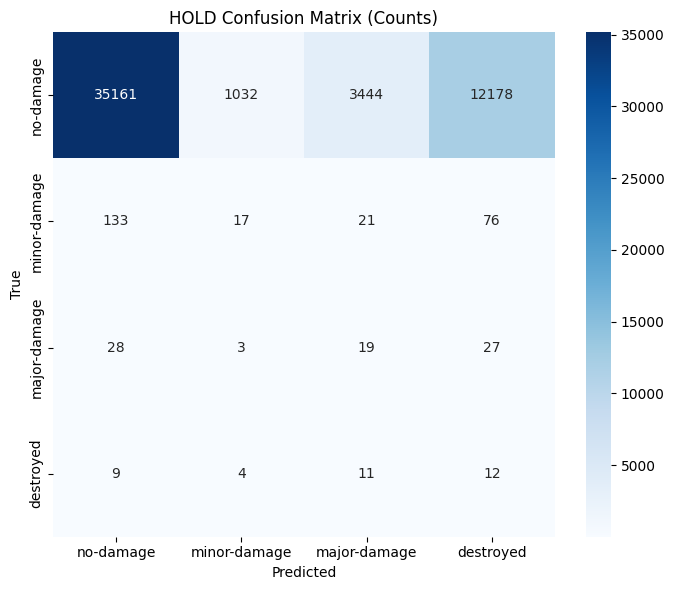

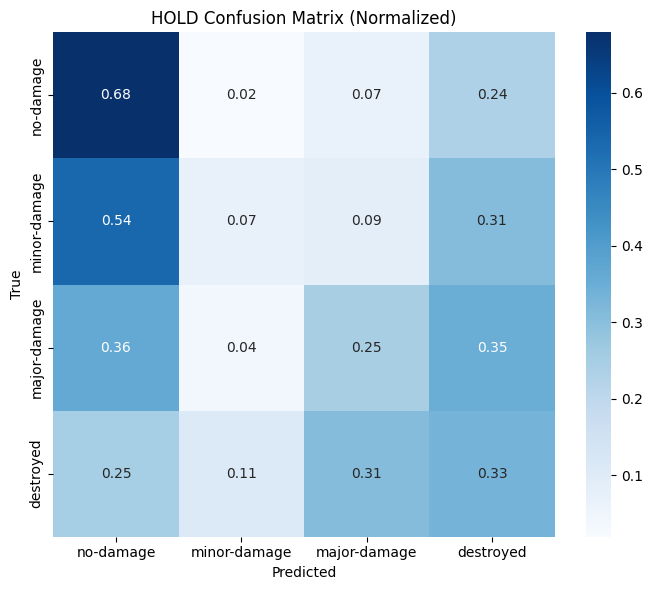

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

# =========================
# Configuration
# =========================

split = "hold"   

labels = ["no-damage", "minor-damage", "major-damage", "destroyed"]

PROJECT_ROOT = Path.cwd()

candidate_paths = [
    PROJECT_ROOT / "OOD_training_outputs" / "baseline_resnet50",
    Path.home() / "Desktop" / "OOD_training_outputs" / "baseline_resnet50",
]

BASE_PATH = None
y_true_path = None
y_pred_path = None

# =========================
# Search logic (robust)
# =========================

for path in candidate_paths:
    
    # Try standard naming
    standard_true = path / f"{split}_targets.npy"
    standard_pred = path / f"{split}_preds.npy"
    
    # Try OOD naming
    ood_true = path / f"OOD_{split}_targets.npy"
    ood_pred = path / f"OOD_{split}_preds.npy"
    
    if standard_true.exists() and standard_pred.exists():
        BASE_PATH = path
        y_true_path = standard_true
        y_pred_path = standard_pred
        print("Using standard split naming")
        break
        
    elif ood_true.exists() and ood_pred.exists():
        BASE_PATH = path
        y_true_path = ood_true
        y_pred_path = ood_pred
        print("Using OOD split naming")
        break

# =========================
# Fail clearly if not found
# =========================

if BASE_PATH is None:
    print("Files not found. Available .npy files:\n")
    for path in candidate_paths:
        if path.exists():
            print(f"\n{path}:")
            for f in path.glob("*.npy"):
                print("  ", f.name)
    
    raise FileNotFoundError("Could not find matching prediction files.")

print(f"\nUsing files:\n{y_true_path}\n{y_pred_path}")

# =========================
# Load predictions
# =========================

y_true = np.load(y_true_path)
y_pred = np.load(y_pred_path)

# =========================
# Confusion matrices
# =========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"{split.upper()} Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"{split.upper()} Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()